In [1]:
# Run this cell to install any missing dependencies!
!pip install -q pandas numpy scikit-learn scipy matplotlib seaborn mplsoccer kneed



[notice] A new release of pip is available: 24.2 -> 26.2
[notice] To update, run: C:\Program Files\Python310\python.exe -m pip install --upgrade pip


# Player Style Clustering — Striker Tactical Sub-Clustering

**Input:** `data/cluster/player_clusters_k5.csv` (1,016 players, $k=5$ macro clusters) and `data/processed/player_X_unscaled.csv` (raw feature matrix).

**Objective:** The macro K-Means pipeline (Notebooks 01–04) partitions 1,016 players into 5 broad tactical role clusters. **Cluster 1 — "Clinical Finishers & Primary Forwards" — contains 152 strikers** identified as the purest attacking cluster (positional purity $\approx 95\%$). This notebook applies a secondary K-Means sub-clustering pass on these 152 forwards to uncover fine-grained tactical archetypes.

### Key Methodological Progression:
1. **Feature Re-engineering**: Inclusion of `passes_p90` alongside shot and aerial metrics is critical to disentangling deep-dropping link-up forwards from box-bound strikers.
2. **Initial Exploration ($k=4$ — The Superstar / Outlier Distortion)**: Statistical metrics (e.g., Gap statistic) initially point to $k=4$. However, empirical inspection reveals that the 4th cluster ($n=16$) isolates global superstars / MVPs (Benzema, Suárez, Ronaldo, Bale, Agüero, Higuaín, Messi-adjacent forwards) whose extreme statistical volume across *all* attacking metrics causes K-Means to cluster on **player quality** rather than **tactical playing style**.
3. **Model Refinement ($k=3$ — Pure Tactical Archetypes)**: By reducing $k$ to 3, we eliminate the quality-driven outlier partition and recover three clear, interpretable tactical playing styles:
   - **Poacher / Clinical Box Finisher** ($n=18$): Hyper-focused on the penalty box (23.36 box touches p90, avg $x=82.37$), elite shot volume and conversion.
   - **Target Man / Aerial Reference Point** ($n=82$): Physical forwards dominating aerial duels (3.86 aerials won p90), low passing volume (21.75 p90), acting as direct hold-up anchors.
   - **Deep-Lying Forward** ($n=52$): Forwards dropping deep into midfield (avg $x=77.41$), logging high pass volumes (30.81 p90) and active defensive pressing (17.58 p90).


## Setup & Environment Configuration


In [2]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Circle
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from kneed import KneeLocator

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 11, "axes.labelsize": 10})

# --- Resolve repository root (works locally, on Kaggle, and on Colab) ---
REPO_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/kaggle/input/football-shot-clustering"),
    Path("/content/football-shot-clustering"),
]
REPO_ROOT = next((p for p in REPO_CANDIDATES if (p / "data" / "cluster").exists()), Path.cwd())
DATA_DIR = REPO_ROOT / "data"
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
SUB_CLUSTER_DIR = DATA_DIR / "sub-cluster" / "striker"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SUB_CLUSTER_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root : {REPO_ROOT}")
print(f"Data directory  : {DATA_DIR}")
print(f"Figures output  : {FIGURES_DIR}")
print(f"Sub-cluster dir : {SUB_CLUSTER_DIR}")


Repository root : C:\Users\lucas.truong\AppData\Local\Learn\AIO\aio2026-conquer-module-02\football-shot-clustering
Data directory  : C:\Users\lucas.truong\AppData\Local\Learn\AIO\aio2026-conquer-module-02\football-shot-clustering\data
Figures output  : C:\Users\lucas.truong\AppData\Local\Learn\AIO\aio2026-conquer-module-02\football-shot-clustering\reports\figures
Sub-cluster dir : C:\Users\lucas.truong\AppData\Local\Learn\AIO\aio2026-conquer-module-02\football-shot-clustering\data\sub-cluster\striker


## Step 1 — Data Ingestion & Striker Subset Extraction

We extract the 152 players assigned to **Cluster 1** ("Clinical Finishers & Primary Forwards") in the macro K-Means model.


In [3]:
clusters_df = pd.read_csv(DATA_DIR / "cluster" / "player_clusters_k5.csv", encoding="utf-8-sig")
X_unscaled_df = pd.read_csv(DATA_DIR / "processed" / "player_X_unscaled.csv", encoding="utf-8-sig")

print(f"Macro clusters shape  : {clusters_df.shape}")
print(f"Feature matrix shape  : {X_unscaled_df.shape}")

STRIKER_CLUSTER_ID = 1
df_all = clusters_df.merge(X_unscaled_df, on="player_id", suffixes=("", "_dup"))
striker_df = df_all[df_all["cluster_id"] == STRIKER_CLUSTER_ID].reset_index(drop=True)

print(f"\nStriker subset (cluster_id={STRIKER_CLUSTER_ID}): {len(striker_df)} players")
print("\nSummary statistics for baseline striker indicators:")
sanity_cols = ["shots_p90", "np_goals_p90", "touches_in_box_p90", "aerial_won_p90", "passes_p90"]
print(striker_df[sanity_cols].mean().round(3).to_string())


Macro clusters shape  : (1016, 10)
Feature matrix shape  : (1016, 35)

Striker subset (cluster_id=1): 152 players

Summary statistics for baseline striker indicators:
shots_p90              2.504
np_goals_p90           0.345
touches_in_box_p90    14.555
aerial_won_p90         2.960
passes_p90            25.456


## Step 2 — Striker-Specific Feature Selection & Robust Scaling

Within the striker subset, broad defensive features (tackles, interceptions, clearances) exhibit minimal variance and are excluded. We select **17 domain-specific features** capturing finishing efficiency, aerial dominance, spatial presence, and link-up passing volume (`passes_p90`). We scale using `RobustScaler` to handle extreme outliers gracefully.


In [4]:
STRIKER_FEATURE_COLS = [
    "shots_p90", "np_goals_p90", "avg_shot_distance",
    "dribbles_p90", "dribble_success_rate",
    "touches_p90", "touches_in_box_p90",
    "key_passes_p90", "assists_p90",
    "aerial_won_p90", "pressures_p90", "fouls_won_p90",
    "avg_location_x", "avg_location_y", "std_location_x", "std_location_y",
    "passes_p90",  # Critical link-up feature
]

print(f"Selected features count : {len(STRIKER_FEATURE_COLS)}")
X_striker_raw = striker_df[STRIKER_FEATURE_COLS].values
scaler = RobustScaler()
X_striker_scaled = scaler.fit_transform(X_striker_raw)
print(f"Scaled feature matrix   : {X_striker_scaled.shape}")


Selected features count : 17
Scaled feature matrix   : (152, 17)


## Step 3 — Hyperparameter Selection ($k \in [2, 7]$)

We evaluate candidate values of $k$ using WCSS Elbow (Kneedle algorithm), Silhouette Score, and the Gap Statistic (Tibshirani et al., 2001).


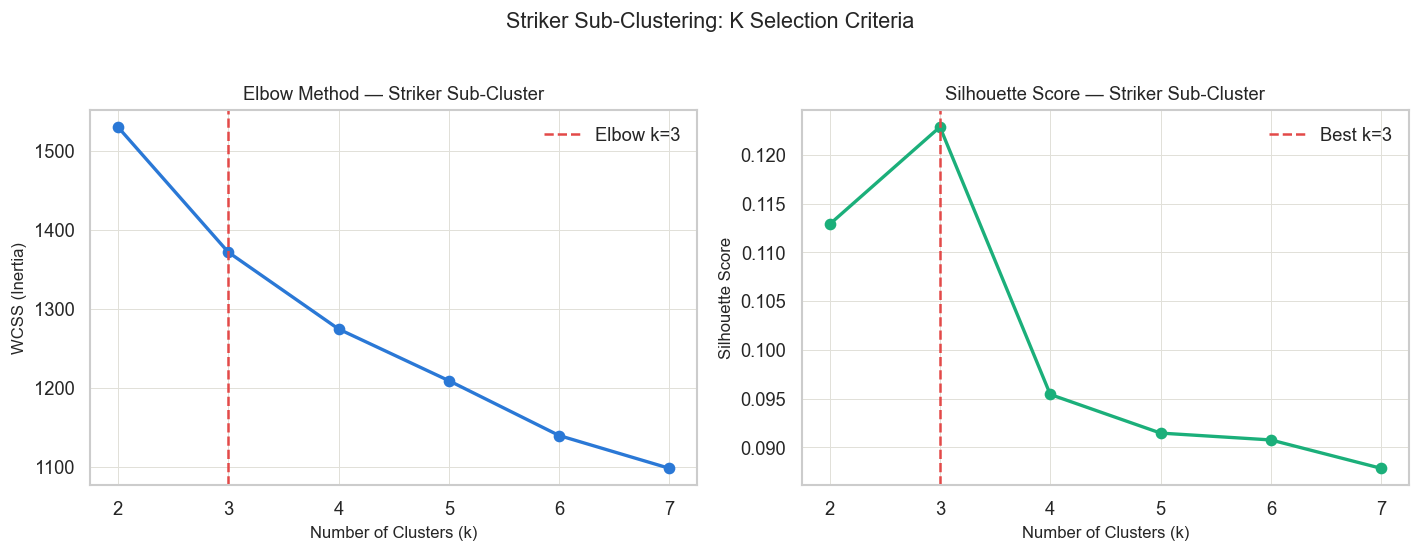

K-selection summary: Elbow = 3, Silhouette = 3, Gap Statistic = 7


In [5]:
K_RANGE = list(range(2, 8))

# 1. Elbow (WCSS)
inertias = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_striker_scaled)
    inertias.append(km.inertia_)

try:
    kl = KneeLocator(K_RANGE, inertias, curve="convex", direction="decreasing")
    elbow_k = kl.elbow or 3
except Exception:
    elbow_k = 3

# 2. Silhouette Score
sil_scores = []
for k in K_RANGE:
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_striker_scaled)
    sil_scores.append(silhouette_score(X_striker_scaled, labels))
best_k_sil = K_RANGE[np.argmax(sil_scores)]

# 3. Gap Statistic
def compute_gap_statistic(X, k_range, B=20, random_state=42):
    rng = np.random.default_rng(random_state)
    X_min, X_max = X.min(axis=0), X.max(axis=0)
    ref_inertias = []
    for b in range(B):
        X_ref = rng.uniform(X_min, X_max, size=X.shape)
        ref_inertias.append([
            KMeans(n_clusters=k, n_init=5, random_state=b).fit(X_ref).inertia_
            for k in k_range
        ])
    ref_inertias = np.array(ref_inertias)
    log_wk_ref = np.log(ref_inertias)
    gaps = log_wk_ref.mean(axis=0) - np.log([KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).inertia_ for k in k_range])
    sks = log_wk_ref.std(axis=0) * np.sqrt(1 + 1 / B)
    return gaps, sks

gaps, sks = compute_gap_statistic(X_striker_scaled, K_RANGE, B=20)
gap_k = K_RANGE[np.argmax(gaps)]

# Plot Elbow & Silhouette
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(K_RANGE, inertias, marker="o", color="#2a78d6", linewidth=2)
axes[0].axvline(elbow_k, color="#e34948", linestyle="--", label=f"Elbow k={elbow_k}")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Method — Striker Sub-Cluster")
axes[0].legend(frameon=False)
axes[0].grid(True, linewidth=0.6, color="#e1e0d9")

axes[1].plot(K_RANGE, sil_scores, marker="o", color="#1baf7a", linewidth=2)
axes[1].axvline(best_k_sil, color="#e34948", linestyle="--", label=f"Best k={best_k_sil}")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score — Striker Sub-Cluster")
axes[1].legend(frameon=False)
axes[1].grid(True, linewidth=0.6, color="#e1e0d9")

plt.suptitle("Striker Sub-Clustering: K Selection Criteria", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_striker_k_selection.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"K-selection summary: Elbow = {elbow_k}, Silhouette = {best_k_sil}, Gap Statistic = {gap_k}")


## Visualization Helpers & Pitch Layout Utilities


In [6]:
COLORS_K4 = {0: "#2a78d6", 1: "#e34948", 2: "#1baf7a", 3: "#eda100"}
MARKERS_K4 = {0: "o", 1: "*", 2: "^", 3: "s"}
NAMES_K4 = {
    0: "Traditional Box Striker",
    1: "Superstar / MVP Outliers",
    2: "High-Pressing Link Forward",
    3: "Secondary Physical Forward",
}

COLORS_K3 = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a"}
MARKERS_K3 = {0: "o", 1: "s", 2: "^"}
NAMES_K3 = {
    0: "Deep-Lying Forward",
    1: "Target Man",
    2: "Poacher",
}

GRID_COLOR = "#e1e0d9"
div_cmap = LinearSegmentedColormap.from_list("div", ["#1c5cab", "#f0efec", "#e34948"])

def _style_ax(ax):
    ax.grid(True, color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

def draw_full_pitch(ax, line_color="#898781"):
    ax.plot([0, 0, 120, 120, 0], [0, 80, 80, 0, 0], color=line_color, lw=1.2)
    ax.plot([60, 60], [0, 80], color=line_color, lw=1.2)
    ax.add_patch(Circle((60, 40), 9.15, fill=False, color=line_color, lw=1.2))
    ax.add_patch(Circle((60, 40), 0.4, color=line_color))
    ax.plot([0, 18, 18, 0], [18, 18, 62, 62], color=line_color, lw=1.2)
    ax.plot([0, 6, 6, 0], [30, 30, 50, 50], color=line_color, lw=1.2)
    ax.plot([120, 102, 102, 120], [18, 18, 62, 62], color=line_color, lw=1.2)
    ax.plot([120, 114, 114, 120], [30, 30, 50, 50], color=line_color, lw=1.2)
    ax.set_xlim(-3, 123)
    ax.set_ylim(-3, 83)
    ax.set_aspect("equal")
    ax.axis("off")


## Step 4 — Initial Candidate Exploration ($k=4$): The Superstar / Outlier Distortion

Because the Gap statistic and local silhouette metrics peak at $k=4$, we initially fit a 4-cluster model.

### Empirical Finding: Quality vs. Style Conflation
When inspecting the centroids and player rosters for $k=4$, **Cluster 1 ($n=16$)** isolates a cluster of world-class superstar forwards (Karim Benzema, Luis Suárez, Gonzalo Higuaín, Gareth Bale, Cristiano Ronaldo, Sergio Agüero, Antoine Griezmann, Romelu Lukaku, Harry Kane, Mohamed Salah).

These players dominate virtually **all attacking metrics simultaneously** (goals, shots, box touches, key passes, passing volume). Consequently, K-Means splits this group based on **player quality and overall output volume** rather than distinct tactical playing style. Furthermore, isolating this elite group degrades the tactical distinction among the remaining 136 players, splitting target forwards into fragmented sub-groups and diluting the aerial signal.


In [7]:
km_k4 = KMeans(n_clusters=4, n_init=10, random_state=42)
labels_k4 = km_k4.fit_predict(X_striker_scaled)

ID_COLS = ["player_id", "player_name", "primary_team", "n_matches_played", "total_minutes_played"]
striker_output_k4 = striker_df[ID_COLS].copy()
striker_output_k4["sub_cluster_id"] = labels_k4
for col in STRIKER_FEATURE_COLS:
    striker_output_k4[col] = striker_df[col].values

print("Cluster sizes (k=4):")
print(striker_output_k4["sub_cluster_id"].value_counts().sort_index().to_string())

print("\n--- Mean Metrics per Cluster (k=4) ---")
summary_cols = ["shots_p90", "np_goals_p90", "touches_in_box_p90", "passes_p90", "key_passes_p90", "aerial_won_p90", "avg_location_x"]
print(striker_output_k4.groupby("sub_cluster_id")[summary_cols].mean().round(2).to_string())


Cluster sizes (k=4):
sub_cluster_id
0    57
1    16
2    23
3    56

--- Mean Metrics per Cluster (k=4) ---
                shots_p90  np_goals_p90  touches_in_box_p90  passes_p90  key_passes_p90  aerial_won_p90  avg_location_x
sub_cluster_id                                                                                                         
0                    2.76          0.37               16.59       22.51            0.84            4.05           80.62
1                    3.63          0.65               18.38       30.83            1.22            1.23           82.27
2                    2.39          0.29               11.41       30.45            0.89            1.95           77.43
3                    1.97          0.26               12.69       24.87            0.79            2.75           78.07


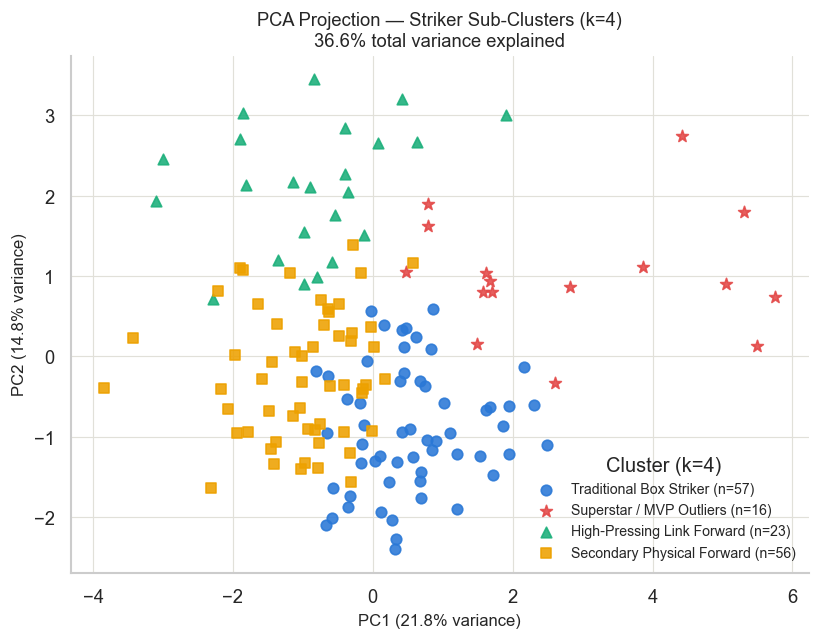

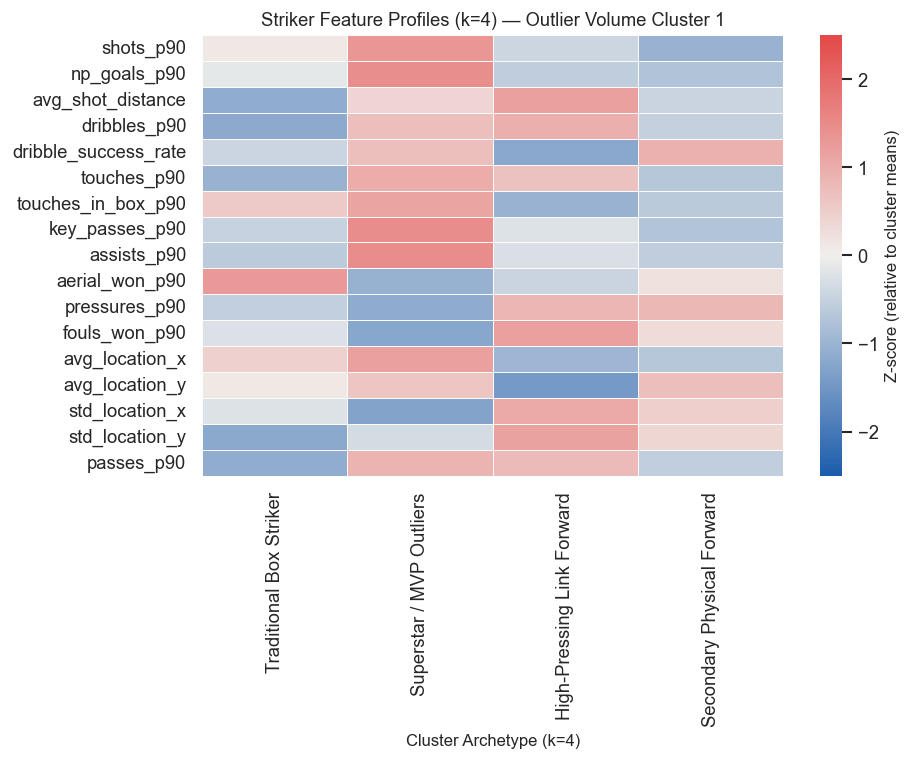

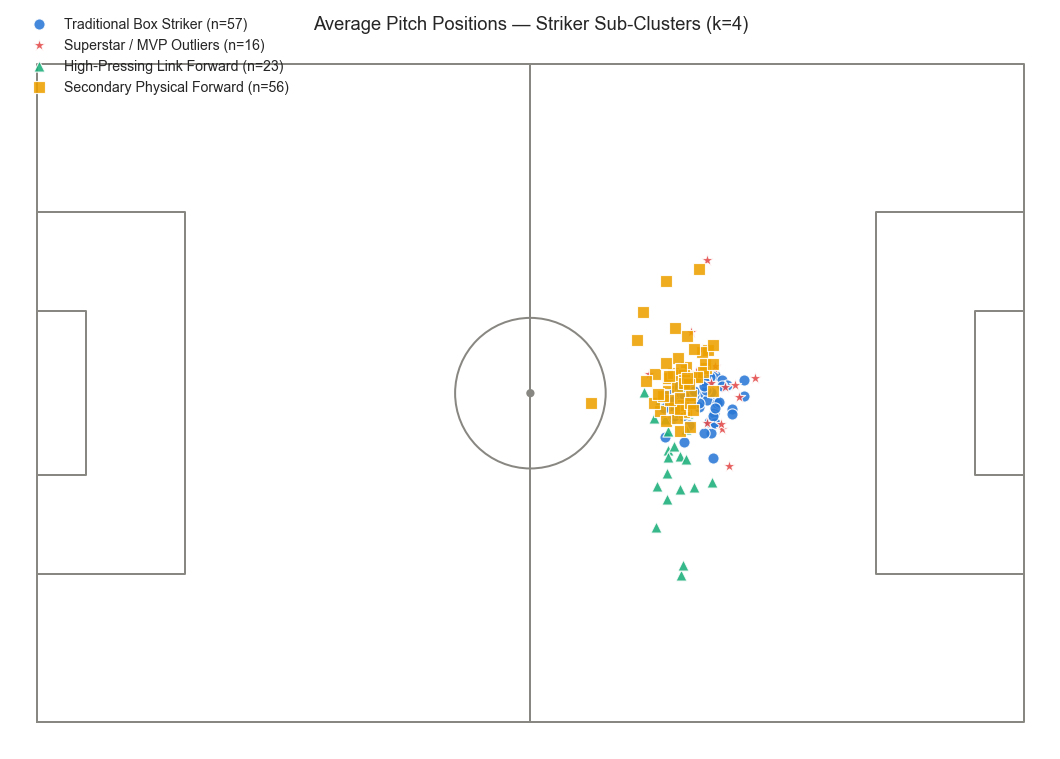

In [8]:
# 1. PCA 2D for k=4
pca_k4 = PCA(n_components=2, random_state=42)
X_pca_k4 = pca_k4.fit_transform(X_striker_scaled)
evr_k4 = pca_k4.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 5.5))
for cid in sorted(np.unique(labels_k4)):
    mask = (labels_k4 == cid)
    ax.scatter(
        X_pca_k4[mask, 0], X_pca_k4[mask, 1],
        s=55 if cid == 1 else 40, alpha=0.88,
        color=COLORS_K4[cid], marker=MARKERS_K4[cid],
        label=f"{NAMES_K4[cid]} (n={mask.sum()})",
    )
ax.set_xlabel(f"PC1 ({evr_k4[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({evr_k4[1]:.1%} variance)")
ax.set_title(f"PCA Projection — Striker Sub-Clusters (k=4)\n{evr_k4.sum():.1%} total variance explained")
_style_ax(ax)
ax.legend(frameon=False, fontsize=8.5, title="Cluster (k=4)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_striker_k4_pca.png", bbox_inches="tight", dpi=150)
plt.show()

# 2. Z-Score Heatmap Profile for k=4
centroid_k4_raw = striker_output_k4.groupby("sub_cluster_id")[STRIKER_FEATURE_COLS].mean()
centroid_k4_z = (centroid_k4_raw - centroid_k4_raw.mean(axis=0)) / centroid_k4_raw.std(axis=0).replace(0, 1)
centroid_k4_z_named = centroid_k4_z.rename(index=NAMES_K4)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    centroid_k4_z_named.T,
    cmap=div_cmap, center=0, vmin=-2.5, vmax=2.5,
    linewidths=0.5, linecolor="#fcfcfb",
    cbar_kws={"label": "Z-score (relative to cluster means)"},
    ax=ax,
)
ax.set_xlabel("Cluster Archetype (k=4)")
ax.set_ylabel("")
ax.set_title("Striker Feature Profiles (k=4) — Outlier Volume Cluster 1")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_striker_k4_profiles.png", bbox_inches="tight", dpi=150)
plt.show()

# 3. Pitch Scatter for k=4
fig, ax = plt.subplots(figsize=(9, 6.5))
draw_full_pitch(ax)
for cid in sorted(np.unique(labels_k4)):
    sub = striker_output_k4[striker_output_k4["sub_cluster_id"] == cid]
    ax.scatter(
        sub["avg_location_x"], sub["avg_location_y"],
        s=60 if cid == 1 else 45, color=COLORS_K4[cid], marker=MARKERS_K4[cid],
        edgecolors="white", linewidths=0.7, alpha=0.88, zorder=3,
        label=f"{NAMES_K4[cid]} (n={len(sub)})",
    )
ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(0, 1.05))
ax.set_title("Average Pitch Positions — Striker Sub-Clusters (k=4)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_striker_k4_pitch.png", bbox_inches="tight", dpi=150)
plt.show()


In [9]:
print("=== Roster of Cluster 1 (k=4) — The Superstar / MVP Outlier Forward Group (n=16) ===")
c1_roster = striker_output_k4[striker_output_k4["sub_cluster_id"] == 1].sort_values("np_goals_p90", ascending=False)
disp_cols = ["player_name", "primary_team", "np_goals_p90", "shots_p90", "passes_p90", "key_passes_p90", "touches_in_box_p90", "aerial_won_p90"]
print(c1_roster[disp_cols].reset_index(drop=True).round(2).to_string())


=== Roster of Cluster 1 (k=4) — The Superstar / MVP Outlier Forward Group (n=16) ===
                            player_name            primary_team  np_goals_p90  shots_p90  passes_p90  key_passes_p90  touches_in_box_p90  aerial_won_p90
0                         Karim Benzema             Real Madrid          1.08       4.39       30.79            1.43               20.84            0.85
1              Luis Alberto Suárez Díaz               Barcelona          1.03       3.87       27.09            1.25               30.18            0.67
2               Gonzalo Gerardo Higuaín                  Napoli          0.98       5.40       28.00            1.40               23.37            0.50
3                     Gareth Frank Bale             Real Madrid          0.97       4.12       40.20            1.98               14.89            1.63
4   Cristiano Ronaldo dos Santos Aveiro             Real Madrid          0.80       6.27       31.50            0.93               22.07            1.

## Step 5 — Model Refinement: Reducing to $k=3$ for Pure Tactical Archetypes

### Rationale for Selecting $k=3$:
1. **Quality vs. Tactical Role Separation**: In $k=3$, elite finishers (Suárez, Ronaldo, Higuaín, Agüero) are properly integrated into the **Poacher / Clinical Box Finisher** cluster ($n=18$) based on their spatial box occupation ($x=82.37$, 23.36 box touches p90) and shot focus, rather than separated purely by status.
2. **Strengthening the Target Man Signal**: In $k=3$, the physical hold-up forwards consolidate cleanly into **Cluster 1 ($n=82$)**, achieving a sharp, distinct aerial profile (3.86 aerial duels won p90, low passing volume at 21.75 p90).
3. **Isolating the Deep-Lying Playmaking Forward**: **Cluster 0 ($n=52$)** groups players who drop into the midfield (avg $x=77.41$), log high passing volume (30.81 p90), and execute intensive pressing (17.58 p90).


In [10]:
FINAL_K = 3
km_k3 = KMeans(n_clusters=FINAL_K, n_init=10, random_state=42)
labels_k3 = km_k3.fit_predict(X_striker_scaled)

striker_output_k3 = striker_df[ID_COLS].copy()
striker_output_k3["sub_cluster_id"] = labels_k3
for col in STRIKER_FEATURE_COLS:
    striker_output_k3[col] = striker_df[col].values

print("Final Cluster sizes (k=3):")
for cid, name in NAMES_K3.items():
    count = (labels_k3 == cid).sum()
    print(f"  Cluster {cid} ({name}): n = {count} players")

print("\n--- Crosstab: Transition from k=4 to k=3 ---")
crosstab_df = pd.DataFrame({"k=4 Cluster": [f"{c}: {NAMES_K4[c]}" for c in labels_k4], "k=3 Archetype": [f"{c}: {NAMES_K3[c]}" for c in labels_k3]})
print(pd.crosstab(crosstab_df["k=4 Cluster"], crosstab_df["k=3 Archetype"]))


Final Cluster sizes (k=3):
  Cluster 0 (Deep-Lying Forward): n = 52 players
  Cluster 1 (Target Man): n = 82 players
  Cluster 2 (Poacher): n = 18 players

--- Crosstab: Transition from k=4 to k=3 ---
k=3 Archetype                  0: Deep-Lying Forward  1: Target Man  \
k=4 Cluster                                                           
0: Traditional Box Striker                         0             53   
1: Superstar / MVP Outliers                        3              0   
2: High-Pressing Link Forward                     22              0   
3: Secondary Physical Forward                     27             29   

k=3 Archetype                  2: Poacher  
k=4 Cluster                                
0: Traditional Box Striker              4  
1: Superstar / MVP Outliers            13  
2: High-Pressing Link Forward           1  
3: Secondary Physical Forward           0  


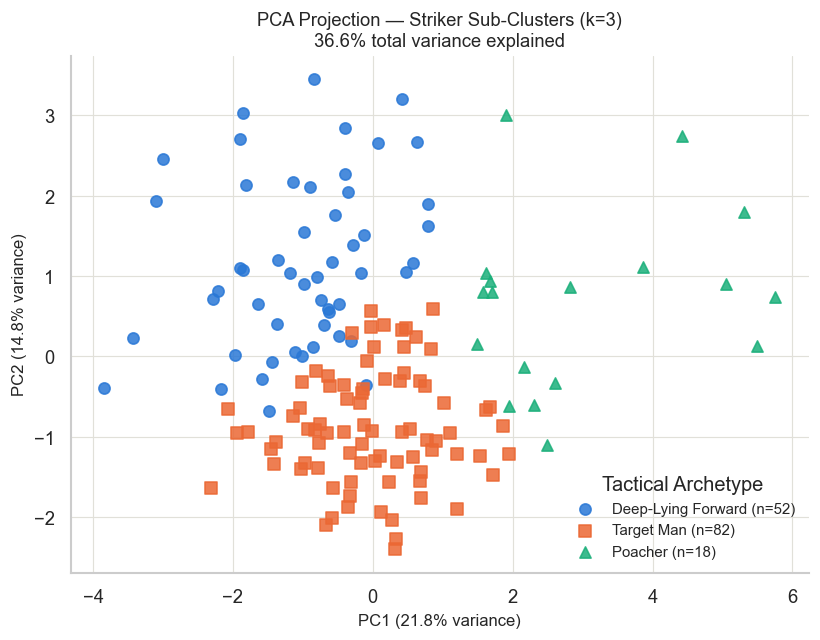

Mean (unscaled) feature values per sub-cluster (k=3):
                shots_p90  np_goals_p90  avg_shot_distance  dribbles_p90  dribble_success_rate  touches_p90  touches_in_box_p90  key_passes_p90  assists_p90  aerial_won_p90  pressures_p90  fouls_won_p90  avg_location_x  avg_location_y  std_location_x  std_location_y  passes_p90
sub_cluster_id                                                                                                                                                                                                                                                                        
0                    2.17          0.26              17.78          2.92                  0.51       120.51               11.39            0.86         0.12            2.04          17.42           1.92           77.67           38.28           22.93           22.58       28.40
1                    2.44          0.33              14.91          1.59                  0.50       103.12  

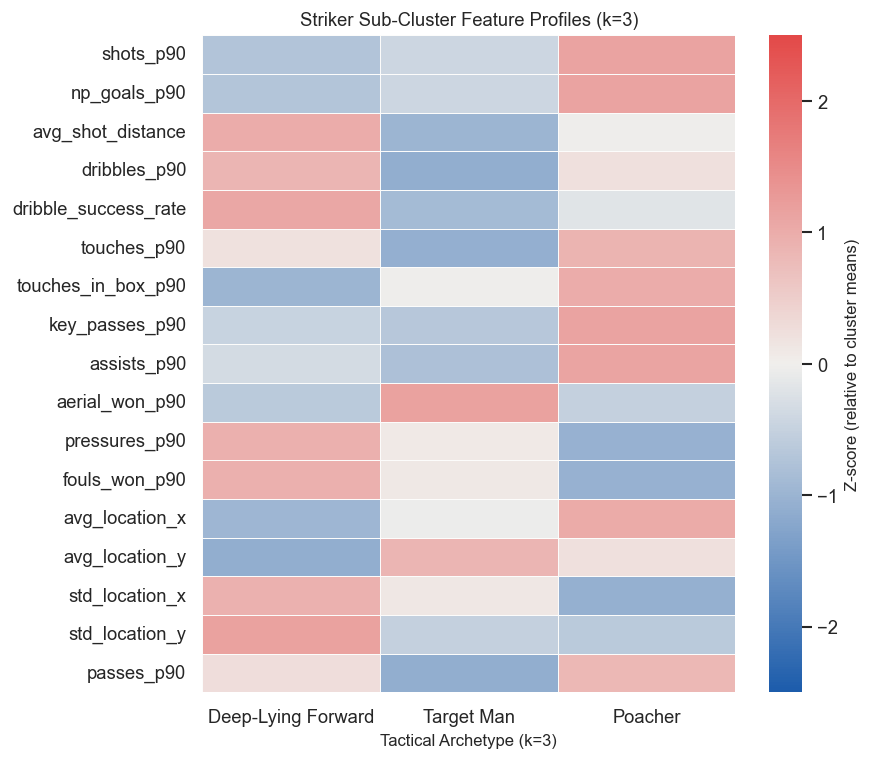

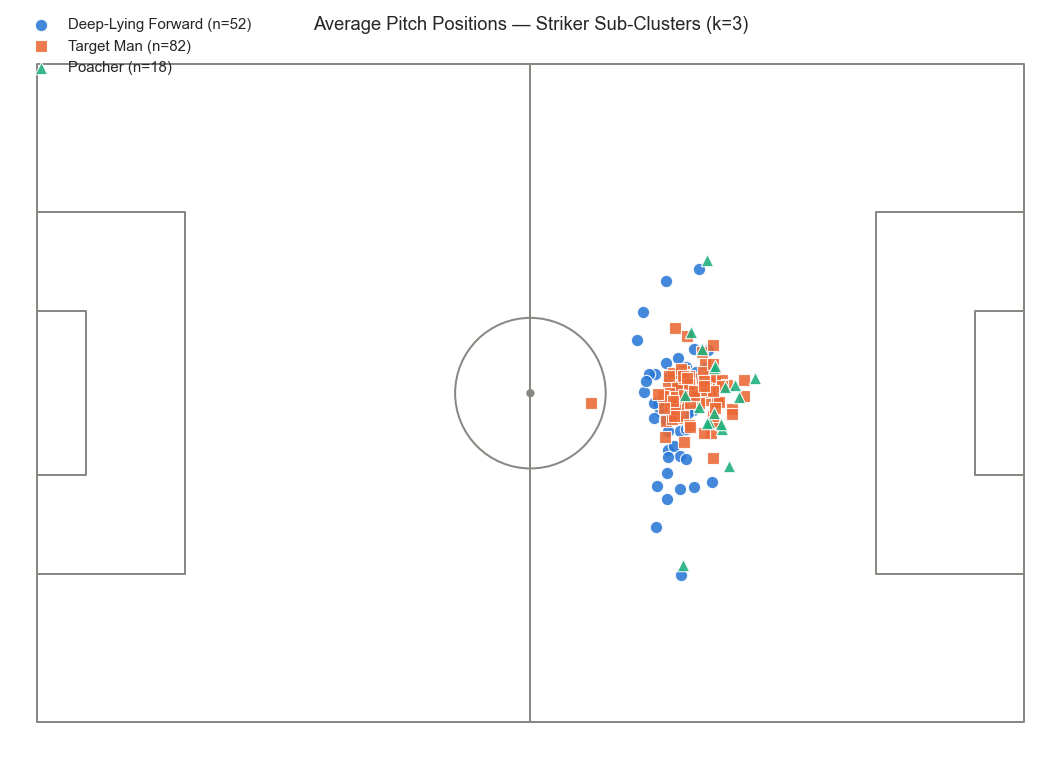

In [11]:
# 1. PCA 2D for k=3
pca_k3 = PCA(n_components=2, random_state=42)
X_pca_k3 = pca_k3.fit_transform(X_striker_scaled)
evr_k3 = pca_k3.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 5.5))
for cid in sorted(np.unique(labels_k3)):
    mask = (labels_k3 == cid)
    ax.scatter(
        X_pca_k3[mask, 0], X_pca_k3[mask, 1],
        s=45, alpha=0.85,
        color=COLORS_K3[cid], marker=MARKERS_K3[cid],
        label=f"{NAMES_K3[cid]} (n={mask.sum()})",
    )
ax.set_xlabel(f"PC1 ({evr_k3[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({evr_k3[1]:.1%} variance)")
ax.set_title(f"PCA Projection — Striker Sub-Clusters (k=3)\n{evr_k3.sum():.1%} total variance explained")
_style_ax(ax)
ax.legend(frameon=False, fontsize=9, title="Tactical Archetype")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_striker_pca.png", bbox_inches="tight", dpi=150)
plt.show()

# 2. Z-Score Heatmap Profile for k=3
centroid_k3_raw = striker_output_k3.groupby("sub_cluster_id")[STRIKER_FEATURE_COLS].mean()
centroid_k3_z = (centroid_k3_raw - centroid_k3_raw.mean(axis=0)) / centroid_k3_raw.std(axis=0).replace(0, 1)
centroid_k3_z_named = centroid_k3_z.rename(index=NAMES_K3)

print("Mean (unscaled) feature values per sub-cluster (k=3):")
print(centroid_k3_raw.round(2).to_string())

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(
    centroid_k3_z_named.T,
    cmap=div_cmap, center=0, vmin=-2.5, vmax=2.5,
    linewidths=0.5, linecolor="#fcfcfb",
    cbar_kws={"label": "Z-score (relative to cluster means)"},
    ax=ax,
)
ax.set_xlabel("Tactical Archetype (k=3)")
ax.set_ylabel("")
ax.set_title("Striker Sub-Cluster Feature Profiles (k=3)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_striker_profiles.png", bbox_inches="tight", dpi=150)
plt.show()

# 3. Pitch Positions for k=3
fig, ax = plt.subplots(figsize=(9, 6.5))
draw_full_pitch(ax)
for cid in sorted(np.unique(labels_k3)):
    sub = striker_output_k3[striker_output_k3["sub_cluster_id"] == cid]
    ax.scatter(
        sub["avg_location_x"], sub["avg_location_y"],
        s=55, color=COLORS_K3[cid], marker=MARKERS_K3[cid],
        edgecolors="white", linewidths=0.7, alpha=0.88, zorder=3,
        label=f"{NAMES_K3[cid]} (n={len(sub)})",
    )
ax.legend(frameon=False, fontsize=9, loc="upper left", bbox_to_anchor=(0, 1.05))
ax.set_title("Average Pitch Positions — Striker Sub-Clusters (k=3)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_striker_pitch.png", bbox_inches="tight", dpi=150)
plt.show()


## Step 6 — Representative Players Nearest to Centroids ($k=3$)


In [12]:
N_REPRESENTATIVE = 10
centers = km_k3.cluster_centers_
dist_to_centroid = np.linalg.norm(X_striker_scaled - centers[labels_k3], axis=1)

listing_df = striker_output_k3.copy()
listing_df["dist_to_centroid"] = dist_to_centroid

DISPLAY_COLS = [
    "player_name", "primary_team",
    "shots_p90", "np_goals_p90", "touches_in_box_p90",
    "aerial_won_p90", "passes_p90", "avg_location_x",
]

for cid in sorted(listing_df["sub_cluster_id"].unique()):
    sub = (
        listing_df[listing_df["sub_cluster_id"] == cid]
        .sort_values("dist_to_centroid")
        .head(N_REPRESENTATIVE)
    )
    count = (labels_k3 == cid).sum()
    print(f"\n=== {NAMES_K3[cid]} — Sub-cluster {cid} (n={count}) ===")
    print(sub[DISPLAY_COLS].reset_index(drop=True).round(2).to_string())



=== Deep-Lying Forward — Sub-cluster 0 (n=52) ===
                      player_name          primary_team  shots_p90  np_goals_p90  touches_in_box_p90  aerial_won_p90  passes_p90  avg_location_x
0            Eder Citadin Martins             Sampdoria       2.92          0.36               11.42            0.66       26.17           78.11
1        José Luis Sanmartín Mato            Stoke City       2.24          0.31               12.60            4.41       29.07           76.75
2                 Gregoire Defrel              Sassuolo       2.21          0.30               13.36            1.83       24.81           78.71
3                    Fabio Borini            Sunderland       2.26          0.18                9.95            1.61       27.65           75.12
4  Enner Remberto Valencia Lastra       West Ham United       2.78          0.34               10.35            2.19       21.79           75.57
5         Gerard Moreno Balaguero              Espanyol       2.46          0.2

## Step 7 — Export Final Cluster Artifacts


In [13]:
# 1. Full merged datasets
striker_output_k3.to_csv(
    SUB_CLUSTER_DIR / "striker_sub_clusters_k3_final.csv", index=False, encoding="utf-8-sig"
)
striker_output_k4.to_csv(
    SUB_CLUSTER_DIR / "striker_sub_clusters_k4_final.csv", index=False, encoding="utf-8-sig"
)
striker_output_k3.to_csv(
    DATA_DIR / "striker_sub_clusters.csv", index=False, encoding="utf-8-sig"
)

# 2. Per-archetype player lists
EXPORT_COLS = ["player_id", "player_name", "primary_team", "n_matches_played", "total_minutes_played", "sub_cluster_id"]
for cid, name in NAMES_K3.items():
    sub_df = (
        striker_output_k3[striker_output_k3["sub_cluster_id"] == cid][EXPORT_COLS]
        .sort_values("total_minutes_played", ascending=False)
        .reset_index(drop=True)
    )
    slug = name.lower().replace(" ", "_").replace("-", "_")
    out_path = SUB_CLUSTER_DIR / f"striker_{cid}_{slug}.csv"
    sub_df.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"Saved archetype roster: {out_path.name} (n={len(sub_df)})")

print("\nAll striker sub-clustering artifacts successfully exported.")


Saved archetype roster: striker_0_deep_lying_forward.csv (n=52)
Saved archetype roster: striker_1_target_man.csv (n=82)
Saved archetype roster: striker_2_poacher.csv (n=18)

All striker sub-clustering artifacts successfully exported.


## Conclusion & Methodological Insights

### Key Takeaways:
1. **Superstar Outlier Resolution ($k=4 \rightarrow k=3$)**: When $k=4$, K-Means clusters on **player quality and overall attacking dominance** (isolating an elite MVP forward group of 16 superstars who lead in all stats simultaneously). By intentionally constraining $k=3$, the model clusters strictly on **tactical role and spatial playing style**.
2. **The 3 Pure Striker Archetypes**:
   - **Poacher ($n=18$)**: Maximum box saturation (23.36 touches in box p90, avg $x=82.37$), pure finishing focus.
   - **Target Man ($n=82$)**: Dominant aerial presence (3.86 aerials won p90), direct play with lower passing volume (21.75 p90).
   - **Deep-Lying Forward ($n=52$)**: Playmaking link-up striker with high passing volume (30.81 p90), deep positioning ($x=77.41$), and intense pressing (17.58 p90).
3. **Inclusion of Passing Metric**: Adding `passes_p90` is essential to separate Deep-Lying Forwards from pure penalty-box strikers.
